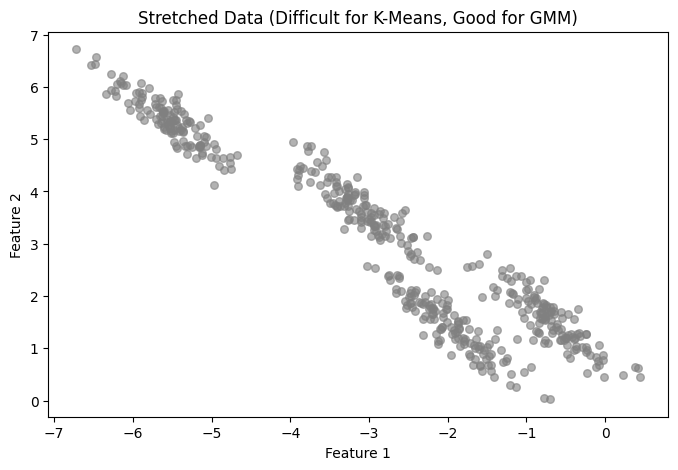

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture

# Set seed
np.random.seed(42)

# 1. Generate Data
# We will generate "stretched" data to demonstrate where GMM shines (and K-Means often fails)
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=0)
X = X[:, ::-1] # Flip axes for better visualization

# Stretch the blobs to make them elliptical
rng = np.random.RandomState(13)
transformation = rng.normal(size=(2, 2))
X = np.dot(X, transformation)

# Visualize the raw data
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], s=30, color='gray', alpha=0.6)
plt.title("Stretched Data (Difficult for K-Means, Good for GMM)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [2]:
# 2. Fit the GMM Model
# covariance_type='full' allows each cluster to have its own general covariance matrix (elliptical shape)
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm.fit(X)

# 3. Predict Labels (Hard Clustering)
labels = gmm.predict(X)

# 4. Predict Probabilities (Soft Clustering)
# Let's look at the probability distribution for the first 5 points
probs = gmm.predict_proba(X)
print("Probabilities for the first 5 data points:")
print(probs[:5].round(3))
# Output interpretation: [0.0, 1.0, 0.0, 0.0] means 100% certainty it belongs to Cluster 2

Probabilities for the first 5 data points:
[[1.    0.    0.    0.   ]
 [1.    0.    0.    0.   ]
 [0.    0.    1.    0.   ]
 [0.    0.    1.    0.   ]
 [0.998 0.    0.002 0.   ]]


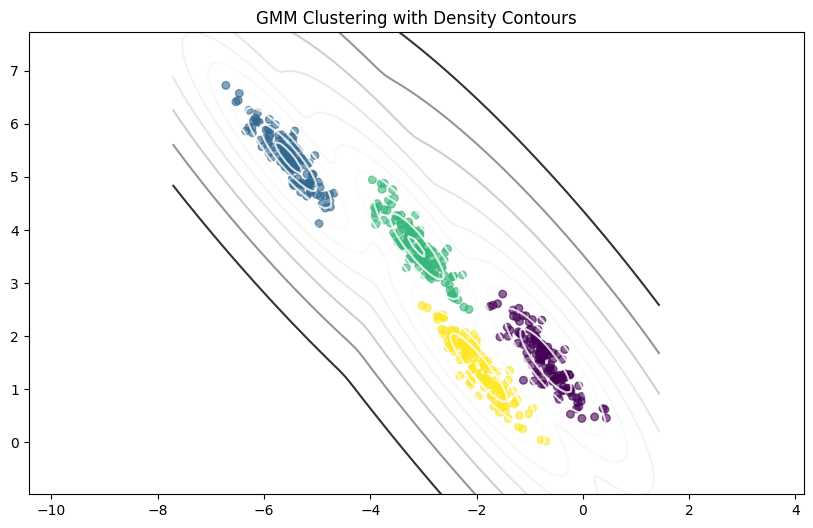

In [3]:
from matplotlib.colors import LogNorm

def plot_gmm(gmm, X, label=True, ax=None):
    ax = ax or plt.gca()
    labels = gmm.fit(X).predict(X)

    # Plot the data points
    if label:
        ax.scatter(X[:, 0], X[:, 1], c=labels, s=30, cmap='viridis', zorder=2, alpha=0.6)
    else:
        ax.scatter(X[:, 0], X[:, 1], s=30, zorder=2, alpha=0.6)

    ax.axis('equal')

    # Create a grid to map the density
    w_factor = 0.2 / gmm.weights_.max()
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = -gmm.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the contour lines (density regions)
    CS = ax.contour(xx, yy, Z, levels=np.logspace(0, 2, 10), cmap='Greys', alpha=0.8)
    return ax

plt.figure(figsize=(10, 6))
plot_gmm(gmm, X)
plt.title("GMM Clustering with Density Contours")
plt.show()

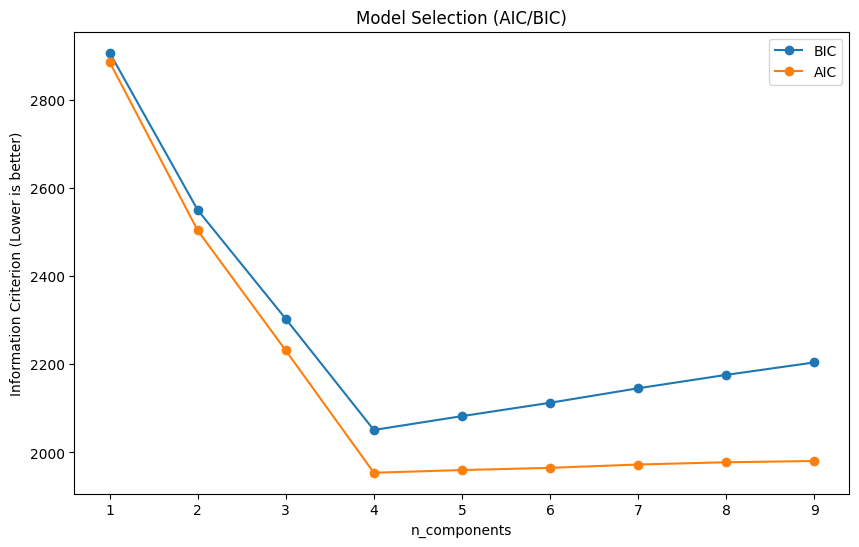

In [4]:
# 5. Determining the optimal number of components using BIC/AIC
n_components = np.arange(1, 10)
models = [GaussianMixture(n, covariance_type='full', random_state=0).fit(X)
          for n in n_components]

plt.figure(figsize=(10, 6))
plt.plot(n_components, [m.bic(X) for m in models], label='BIC', marker='o')
plt.plot(n_components, [m.aic(X) for m in models], label='AIC', marker='o')
plt.legend(loc='best')
plt.xlabel('n_components')
plt.ylabel('Information Criterion (Lower is better)')
plt.title('Model Selection (AIC/BIC)')
plt.show()

# Interpretation: The "elbow" or the lowest point usually indicates the optimal k.
# In this graph, it should bottom out at 4.